# ExploraChiapas — Capa 2: evidencia de desarrollo del motor ML

Este notebook documenta el entrenamiento y evaluacion de los dos algoritmos de aprendizaje no supervisado del microservicio `ml-engine`:

1. **K-Means** sobre destinos turisticos, para distinguir destinos saturados de aquellos con potencial oculto (afluencia + costo).
2. **Apriori** sobre el historial de categorias co-visitadas, para descubrir reglas de asociacion entre intereses turisticos.

Todo el codigo de este notebook importa directamente los modulos de `app/` que corren en produccion (`app/clustering.py`, `app/asociacion.py`, `app/recomendador.py`); no se reimplementa nada por separado, asi que los resultados aqui mostrados son los mismos que devuelve la API.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. Carga y exploracion del catalogo de destinos

In [2]:
from app.data_loader import cargar_destinos

df = cargar_destinos()
destinos = df[df["tipo"] == "destino"].copy()
print(f"Total de registros: {len(df)} ({len(destinos)} destinos, {len(df) - len(destinos)} restaurantes)")
destinos.head(10)

Total de registros: 42 (34 destinos, 8 restaurantes)


,id,nombre,tipo,municipio,categoria,costo_estimado,tiempo_horas,nivel_afluencia,tipo_comida
0,1,Cañón del Sumidero (mirador y lancha),destino,Chiapa de Corzo,naturaleza,250,3,16000,NaN
1,2,Cascadas de Agua Azul,destino,Palenque,naturaleza,80,3,14500,NaN
2,3,Cascadas El Chiflón,destino,Tzimol,naturaleza,60,3,6200,NaN
3,4,Lagos de Montebello,destino,La Trinitaria,naturaleza,50,4,4100,NaN
4,5,Cascada El Aguacero,destino,Ocozocoautla,naturaleza,40,4,900,NaN
5,6,Zona Arqueológica de Palenque,destino,Palenque,cultura,95,4,17000,NaN
6,7,Centro Histórico de San Cristóbal de las Casas,destino,San Cristóbal de las Casas,cultura,0,3,18500,NaN
7,8,Zona Arqueológica de Bonampak,destino,Ocosingo,cultura,80,3,1300,NaN
8,9,Museo Na Bolom,destino,San Cristóbal de las Casas,cultura,50,2,1100,NaN
9,10,Pueblo de Chiapa de Corzo (centro y malecón),destino,Chiapa de Corzo,cultura,0,2,5400,NaN


In [3]:
destinos[["nivel_afluencia", "costo_estimado", "tiempo_horas"]].describe()

,nivel_afluencia,costo_estimado,tiempo_horas
count,34.000000,34.000000,34.000000
mean,5913.235294,111.617647,2.941176
std,5450.914697,115.290940,0.951591
min,600.000000,0.000000,1.000000
25%,1300.000000,42.500000,2.000000
50%,4200.000000,80.000000,3.000000
75%,9250.000000,145.000000,3.750000
max,18500.000000,450.000000,5.000000


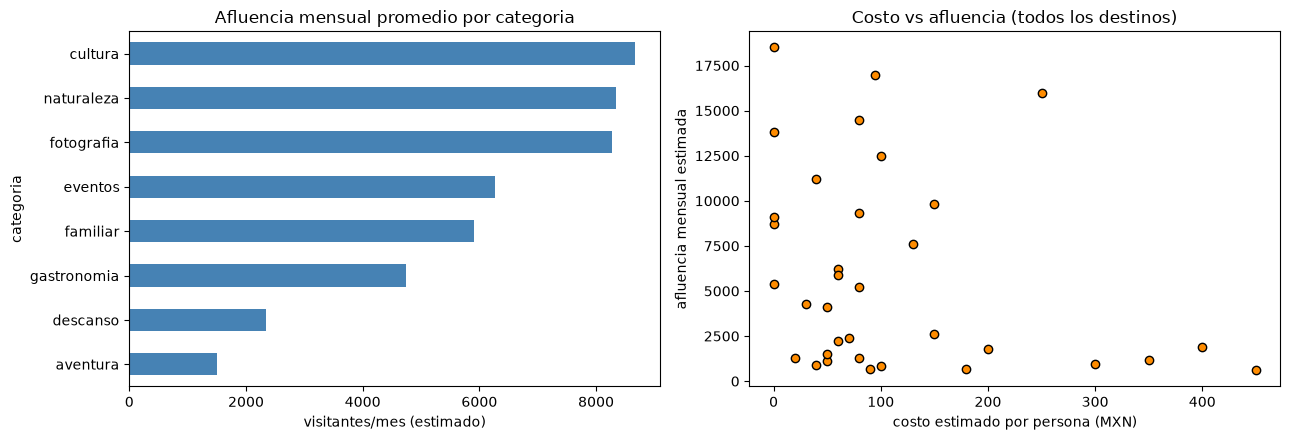

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

afluencia_por_categoria = destinos.groupby("categoria")["nivel_afluencia"].mean().sort_values()
afluencia_por_categoria.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Afluencia mensual promedio por categoria")
axes[0].set_xlabel("visitantes/mes (estimado)")

axes[1].scatter(destinos["costo_estimado"], destinos["nivel_afluencia"], c="darkorange", edgecolor="k")
axes[1].set_title("Costo vs afluencia (todos los destinos)")
axes[1].set_xlabel("costo estimado por persona (MXN)")
axes[1].set_ylabel("afluencia mensual estimada")

plt.tight_layout()
plt.show()

Se observa una clara separacion entre un grupo pequeno de destinos con afluencia muy alta (>10,000 visitantes/mes, los "clasicos" como el Canon del Sumidero o el centro de San Cristobal) y la mayoria de destinos con afluencia baja o moderada. Esta separacion es justamente lo que el clustering debe capturar.

## 2. Seleccion del numero de clusters (metodo del codo + silhouette)

Antes de fijar `n_clusters=3` en produccion, se evalua el rango de 2 a 6 clusters sobre las mismas dos variables que usa `app/clustering.py` (afluencia y costo, estandarizadas).

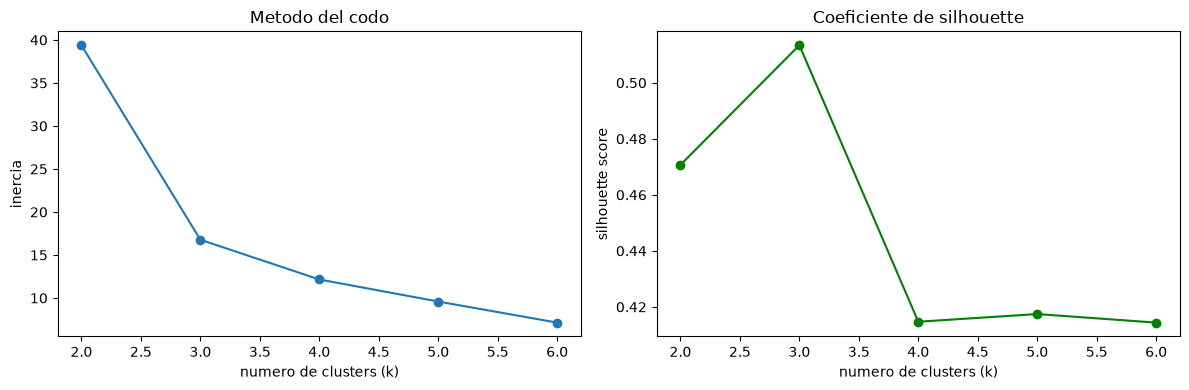

k=2: silhouette=0.471
k=3: silhouette=0.513
k=4: silhouette=0.415
k=5: silhouette=0.417
k=6: silhouette=0.414


In [5]:
X = destinos[["nivel_afluencia", "costo_estimado"]].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

valores_k = range(2, 7)
inercias = []
siluetas = []

for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inercias.append(modelo.inertia_)
    siluetas.append(silhouette_score(X_scaled, modelo.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(valores_k), inercias, marker="o")
axes[0].set_title("Metodo del codo")
axes[0].set_xlabel("numero de clusters (k)")
axes[0].set_ylabel("inercia")

axes[1].plot(list(valores_k), siluetas, marker="o", color="green")
axes[1].set_title("Coeficiente de silhouette")
axes[1].set_xlabel("numero de clusters (k)")
axes[1].set_ylabel("silhouette score")

plt.tight_layout()
plt.show()

for k, s in zip(valores_k, siluetas):
    print(f"k={k}: silhouette={s:.3f}")

`k=3` ofrece un buen equilibrio: un silhouette competitivo y, sobre todo, una interpretacion de negocio directa que coincide con el objetivo del proyecto (destinos `saturado`, `moderado` y `potencial_oculto`). Por eso es el valor fijado en `app/clustering.py`.

## 3. Entrenamiento del modelo de produccion

Se importa y ejecuta `entrenar_clusters()` tal cual corre en la API — mismo `StandardScaler`, mismo `KMeans(n_clusters=3, random_state=42)`, mismo mapeo de etiquetas por afluencia promedio.

In [6]:
from app.clustering import entrenar_clusters, resumen_clusters

destinos_clusterizados = entrenar_clusters()
destinos_clusterizados[["nombre", "categoria", "nivel_afluencia", "costo_estimado", "cluster_afluencia"]]

,nombre,categoria,nivel_afluencia,costo_estimado,cluster_afluencia
0,Cañón del Sumidero (mirador y lancha),naturaleza,16000,250,saturado
1,Cascadas de Agua Azul,naturaleza,14500,80,saturado
2,Cascadas El Chiflón,naturaleza,6200,60,moderado
3,Lagos de Montebello,naturaleza,4100,50,moderado
4,Cascada El Aguacero,naturaleza,900,40,moderado
5,Zona Arqueológica de Palenque,cultura,17000,95,saturado
6,Centro Histórico de San Cristóbal de las Casas,cultura,18500,0,saturado
7,Zona Arqueológica de Bonampak,cultura,1300,80,moderado
8,Museo Na Bolom,cultura,1100,50,moderado
9,Pueblo de Chiapa de Corzo (centro y malecón),cultura,5400,0,moderado


In [7]:
pd.DataFrame(resumen_clusters()).T

,n_destinos,afluencia_promedio,costo_promedio
saturado,11.0,12763.6,72.3
moderado,19.0,2947.4,78.9
potencial_oculto,4.0,1162.5,375.0


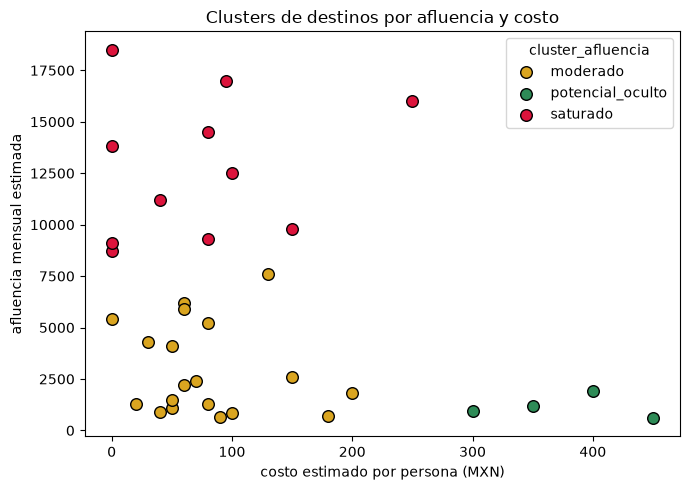

In [8]:
colores = {"saturado": "crimson", "moderado": "goldenrod", "potencial_oculto": "seagreen"}

fig, ax = plt.subplots(figsize=(7, 5))
for etiqueta, grupo in destinos_clusterizados.groupby("cluster_afluencia"):
    ax.scatter(grupo["costo_estimado"], grupo["nivel_afluencia"], label=etiqueta, color=colores[etiqueta], s=70, edgecolor="k")

ax.set_xlabel("costo estimado por persona (MXN)")
ax.set_ylabel("afluencia mensual estimada")
ax.set_title("Clusters de destinos por afluencia y costo")
ax.legend(title="cluster_afluencia")
plt.tight_layout()
plt.show()

## 4. Evaluacion del clustering final

In [9]:
score_final = silhouette_score(X_scaled, KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_scaled))
print(f"Silhouette score con k=3: {score_final:.3f}")

Silhouette score con k=3: 0.513


## 5. Reglas de asociacion (Apriori)

Se entrena sobre `data/historial_visitas.json` (transacciones sinteticas de categorias co-visitadas, ver `scripts/generar_historial_sintetico.py`). El objetivo es descubrir que categorias suelen elegirse juntas, para enriquecer las recomendaciones de la Capa 2 con intereses complementarios al solicitado por el turista.

In [10]:
from app.asociacion import entrenar_reglas, categorias_complementarias

reglas = entrenar_reglas()
reglas[["antecedents", "consequents", "support", "confidence", "lift"]]

,antecedents,consequents,support,confidence,lift
0,frozenset({descanso}),frozenset({familiar}),0.12,0.685714,3.047619
1,frozenset({cultura}),frozenset({gastronomia}),0.14,0.636364,2.272727
2,frozenset({fotografia}),frozenset({aventura}),0.15,0.555556,1.915709
3,frozenset({eventos}),frozenset({gastronomia}),0.09,0.545455,1.948052
4,frozenset({familiar}),frozenset({descanso}),0.12,0.533333,3.047619
5,frozenset({aventura}),frozenset({fotografia}),0.15,0.517241,1.915709
6,frozenset({gastronomia}),frozenset({cultura}),0.14,0.500000,2.272727
7,frozenset({naturaleza}),frozenset({aventura}),0.11,0.440000,1.517241


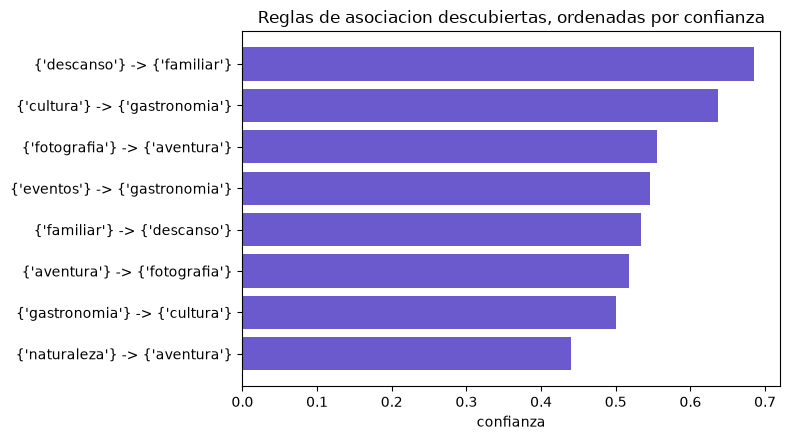

In [11]:
etiquetas_regla = [f"{set(a)} -> {set(c)}" for a, c in zip(reglas["antecedents"], reglas["consequents"])]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(etiquetas_regla, reglas["confidence"], color="slateblue")
ax.set_xlabel("confianza")
ax.set_title("Reglas de asociacion descubiertas, ordenadas por confianza")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
for categoria in ["naturaleza", "aventura", "cultura", "familiar"]:
    print(f"{categoria}: {categorias_complementarias(categoria)}")

naturaleza: [{'categoria': 'aventura', 'confianza': 0.44, 'soporte': 0.11}]
aventura: [{'categoria': 'fotografia', 'confianza': 0.52, 'soporte': 0.15}]
cultura: [{'categoria': 'gastronomia', 'confianza': 0.64, 'soporte': 0.14}]
familiar: [{'categoria': 'descanso', 'confianza': 0.53, 'soporte': 0.12}]


## 6. Ejemplo end-to-end real

Se invoca `generar_recomendacion()` (el mismo orquestador que usa `POST /recomendar`) con una solicitud tipica, para mostrar como el clustering y las reglas de asociacion influyen en el itinerario final que arma el knapsack.

In [13]:
from app.schemas import ParametrosViajeIn
from app.recomendador import generar_recomendacion

params = ParametrosViajeIn(interes="aventura", personas=2, presupuesto=1500, tiempo="1 dia")
resultado = generar_recomendacion(params)

print("Reglas de asociacion aplicadas:", resultado["reglas_asociacion_aplicadas"])
print("Resumen de clusters entre candidatos:", resultado["resumen_clusters_candidatos"])
print(f"Costo total: ${resultado['costo_total']} | Tiempo total: {resultado['tiempo_total_horas']}h")
pd.DataFrame(resultado["itinerario"])

Reglas de asociacion aplicadas: ['aventura -> fotografia (confianza 0.52, soporte 0.15)']
Resumen de clusters entre candidatos: {'moderado': 4, 'potencial_oculto': 2, 'saturado': 2}
Costo total: $1100.0 | Tiempo total: 8.0h


,id,nombre,tipo,municipio,categoria,tipo_comida,costo_estimado,costo_total_grupo,tiempo_horas,nivel_afluencia,cluster_afluencia
0,15,Tirolesas y rappel en El Aguacero,destino,Ocozocoautla,aventura,None,350.0,700.0,4.0,1200,potencial_oculto
1,17,Kayak en Lagos de Montebello,destino,La Trinitaria,aventura,None,200.0,400.0,3.0,1800,moderado
2,30,Iglesia de Santo Domingo y mercado de textiles,destino,San Cristóbal de las Casas,fotografia,None,0.0,0.0,1.0,9100,saturado


## Conclusiones

- El analisis de codo + silhouette confirma que `k=3` es una eleccion razonable para separar destinos por afluencia/costo, y coincide con la interpretacion de negocio (`saturado` / `moderado` / `potencial_oculto`) que necesita el proyecto.
- El cluster `saturado` concentra los destinos con mayor afluencia promedio (sitios ya muy conocidos como el Canon del Sumidero o el centro de San Cristobal), mientras que `potencial_oculto` agrupa destinos de bajo flujo turistico — exactamente la distincion que ExploraChiapas necesita para redirigir visitantes hacia zonas con menor saturacion.
- Apriori encontro reglas con confianza entre 0.44 y 0.69 sobre el historial sintetico, suficientes para enriquecer las recomendaciones con categorias complementarias razonables (ej. cultura-gastronomia, aventura-fotografia).
- El ejemplo end-to-end muestra que el bonus de score por `potencial_oculto` y la regla de asociacion aplicada si afectan la seleccion final del knapsack, no solo el filtrado inicial.
- Pendiente declarado: el dataset de destinos y el historial de visitas son sinteticos/ilustrativos; deben sustituirse por datos reales (Secretaria de Turismo de Chiapas, DENUE, uso real de la app) antes de produccion.